In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [3]:
df = pd.read_csv("../dataset/updated_pollution_dataset.csv")

df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (5000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 390.8 KB


In [5]:
df.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.tail(20)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
4980,22.8,56.6,9.8,15.4,13.8,4.3,1.11,11.7,372,Good
4981,41.5,94.0,62.1,79.4,30.0,20.0,2.80,7.8,547,Hazardous
4982,24.4,53.7,1.6,4.6,24.9,6.0,0.93,10.6,253,Good
4983,31.4,54.3,25.6,34.5,37.0,14.9,1.32,8.3,632,Moderate
4984,28.0,70.3,2.9,8.3,24.7,8.0,0.82,10.5,308,Good
4985,26.8,72.5,2.4,12.8,26.4,13.2,1.38,6.5,484,Moderate
4986,35.6,103.8,74.5,93.3,31.8,23.6,2.04,20.8,757,Hazardous
4987,26.2,63.4,14.7,21.1,19.1,3.7,1.15,14.2,305,Good
4988,26.5,43.0,18.8,18.4,17.6,2.1,1.08,10.6,426,Good
4989,44.4,102.1,35.4,54.7,55.5,25.5,1.79,3.0,772,Hazardous


In [8]:
df.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='str')

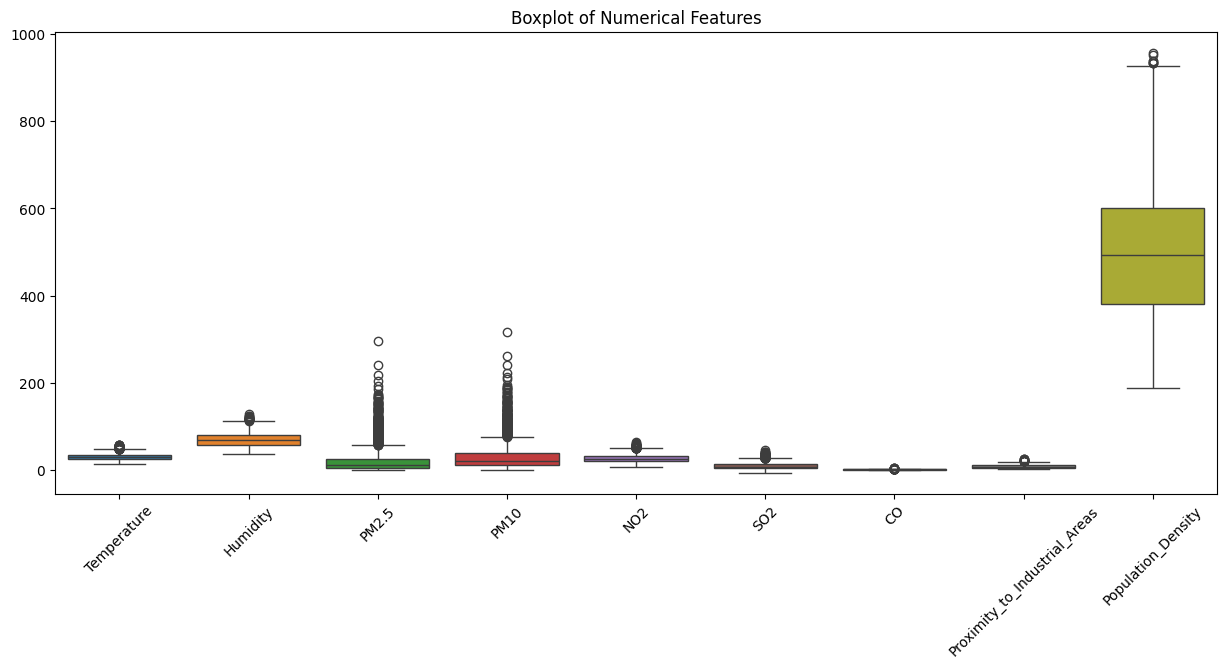

In [9]:
#Detect outliers

plt.figure(figsize=(15,6))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")

plt.show()

In [10]:
#Count outliers

numeric_cols = df.select_dtypes(include='number')

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

IQR = Q3 - Q1

outliers = ((numeric_cols < (Q1 - 1.5 * IQR)) |
            (numeric_cols > (Q3 + 1.5 * IQR)))

outliers.sum()

Temperature                       72
Humidity                          19
PM2.5                            352
PM10                             324
NO2                               73
SO2                              124
CO                                45
Proximity_to_Industrial_Areas     16
Population_Density                 7
dtype: int64

In [11]:
# Handle Outliers Using IQR Capping

df_clean = df.copy()

for column in numeric_cols.columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[column] = np.where(
        df_clean[column] < lower_bound,
        lower_bound,
        df_clean[column]
    )

    df_clean[column] = np.where(
        df_clean[column] > upper_bound,
        upper_bound,
        df_clean[column]
    )

In [12]:
numeric_cols_clean = df_clean.select_dtypes(include='number')

Q1 = numeric_cols_clean.quantile(0.25)
Q3 = numeric_cols_clean.quantile(0.75)

IQR = Q3 - Q1

outliers_after = (
    (numeric_cols_clean < (Q1 - 1.5 * IQR)) |
    (numeric_cols_clean > (Q3 + 1.5 * IQR))
)

outliers_after.sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
dtype: int64

In [14]:
#Data transformation

df_clean["Air Quality"].unique()

<StringArray>
['Moderate', 'Good', 'Hazardous', 'Poor']
Length: 4, dtype: str

In [17]:
#Label Encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_clean["Air Quality"] = encoder.fit_transform(
    df_clean["Air Quality"]
)

df_clean.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319.0,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611.0,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619.0,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551.0,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303.0,0


In [18]:
df_clean["Air Quality"].head()

0    2
1    2
2    2
3    0
4    0
Name: Air Quality, dtype: int64

In [16]:
#Verify Encoding
print(encoder.classes_)

['Good' 'Hazardous' 'Moderate' 'Poor']


In [20]:
# Separate Features and Target

X = df_clean.drop("Air Quality", axis=1)

y = df_clean["Air Quality"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5000, 9)
Target Shape: (5000,)


In [21]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.02701882 -0.69205151 -0.74395391 -0.50076951 -0.85283154 -0.11068132
   0.41081032 -0.59069229 -1.16842807]
 [-0.25560443  0.35207791 -0.9125924  -0.77746725  0.50680332 -0.03291526
   0.26254014 -0.67431395  0.74394964]
 [-1.04803454  0.29512539  0.50629693  0.27107155 -0.22442887  0.41812788
   0.24400637 -0.89730505  0.79634355]
 [-0.43847292 -1.95766291 -0.69161783 -1.06387368 -1.4698087  -0.71725657
  -0.64561467  0.74725434  0.35099532]
 [-0.52990716  0.04200311 -0.64509687 -0.59300209 -0.51006645 -0.67059694
  -0.90508748  1.19323655 -1.27321589]]


In [22]:
#Verify scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,5.186962e-17,-4.142464e-16,-1.776357e-16,-3.481659e-17,-5.115908e-16,1.918465e-16,-5.790923e-17,6.110668e-17,-2.842171e-18
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-2.526221e+00,-2.153833e+00,-1.046340e+00,-1.379406e+00,-2.166764e+00,-2.505876e+00,-1.572303e+00,-1.649900e+00,-2.026378e+00
25%,-7.432537e-01,-7.426760e-01,-7.788446e-01,-7.726129e-01,-7.157255e-01,-7.483630e-01,-8.680199e-01,-8.415573e-01,-7.623753e-01
50%,-1.489311e-01,-1.494940e-02,-3.485257e-01,-3.163044e-01,-1.215993e-01,-2.973199e-01,-1.637366e-01,-1.447101e-01,-2.231129e-02
75%,6.130209e-01,6.494966e-01,4.714062e-01,4.798084e-01,6.324839e-01,5.931015e-01,6.332156e-01,7.472543e-01,6.719080e-01
max,2.647433e+00,2.737755e+00,2.346782e+00,2.358440e+00,2.654798e+00,2.605298e+00,2.885069e+00,3.130472e+00,2.823333e+00


In [23]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

In [24]:
print("Original Features:", X.shape[1])

print("Reduced Features:", X_pca.shape[1])

Original Features: 9
Reduced Features: 7


In [25]:
print("Variance Retained:")

print(sum(pca.explained_variance_ratio_))

Variance Retained:
0.973154760986985


In [26]:
# Save cleaned dataset

df_clean.to_csv(
    "../dataset/cleaned_air_quality.csv",
    index=False
)

In [27]:
# Save PCA dataset

pca_df = pd.DataFrame(X_pca)

pca_df["Air Quality"] = y.values

pca_df.to_csv(
    "../dataset/pca_air_quality.csv",
    index=False
)